In [2]:
# imports
import scqubits as scq
import numpy as np
import matplotlib.pyplot as plt

# Linc

In [3]:
yaml_str = """
branches:
  # two Josephson junctions and inductor in parallel form a SQUID loop between node 1 and ground
  - [JJ, 1, 0, EJ1 = 15.84,  CJ1 = 10000]   # GHz units if no unit suffix provided. These are capacitive charging energies
  - [JJ, 1, 0, EJ2 = 15.84,  CJ2 = 10000]   # use large charging energy to remove junction capacitance
  - [L,  1, 0, Ls = 52.8]              
  # shunt capacitor (sets EC)
  - [C,  1, 0, Csh = 0.1]  # GHz units, capactive charging energy           
"""

circ = scq.Circuit(yaml_str, from_file=False) # create circuit object from yaml string

print(circ.sym_external_fluxes()) # print external flux loops 
print(circ.branches) # print branch labels
print(circ.cutoff_names) # print cutoff parameters 

{Φ1: (Branch(JJ, 1, 0, index: 1), [Branch(JJ, 1, 0, index: 0), Branch(JJ, 1, 0, index: 1)]), Φ2: (Branch(L, 1, 0, index: 2), [Branch(JJ, 1, 0, index: 0), Branch(L, 1, 0, index: 2)])}
[Branch(JJ, 1, 0, index: 0), Branch(JJ, 1, 0, index: 1), Branch(L, 1, 0, index: 2), Branch(C, 1, 0, index: 3)]
['cutoff_ext_1']


In [18]:
closure_idx = [0,1] # want the two JJs in loop to be the closure branches. This is index
closure_branches = [circ.branches[i] for i in closure_idx] # list of branches for the closure branches

# Re-define the loop basis
circ.configure(closure_branches=closure_branches)

# Verify
print(circ.sym_external_fluxes()) # now Φ1, Φ2 correspond to chosen loops above. IMPORTANT: check order of branches which determines line integral direction for flux loops. Note the direction when applying flux
circ.cutoff_ext_1 = 700 # set the cutoff for the hilbert space, in ext case it is fock space since using ladder operators

{Φ1: (Branch(JJ, 1, 0, index: 0), [Branch(L, 1, 0, index: 2), Branch(JJ, 1, 0, index: 0)]), Φ2: (Branch(JJ, 1, 0, index: 1), [Branch(L, 1, 0, index: 2), Branch(JJ, 1, 0, index: 1)])}


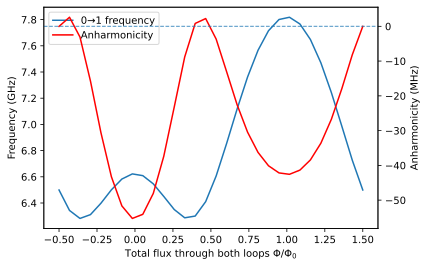

In [21]:
# 1) get the Unicode flux variable names from the circuit
flux_syms  = list(circ.sym_external_fluxes().keys())   # [Symbol('Φ1'), Symbol('Φ2'), ...]
phi1_name  = flux_syms[0].name                          # "Φ1"
phi2_name  = flux_syms[1].name                          # "Φ2"

# 2) sweep a common flux -1 to 1
flux_vals = np.linspace(-0.25, 0.75, 30) # this is equal to flux / Φ0
flux_offset = 0.33 # this is the offset flux for the symmetric point, in units of Φ0

# 3) want symetric flux through both loops
evals_count = 6
evals = np.empty((len(flux_vals), evals_count)) # eigenvalues for each flux value, for the first 6 levels
for i, phi in enumerate(flux_vals):
    setattr(circ, phi1_name, -phi + flux_offset)   # circ.Φ1 = -phi since the loop is defined in the opposite direction
    setattr(circ, phi2_name, phi + flux_offset)   # circ.Φ2 = phi
    evals[i, :] = circ.eigenvals(evals_count=evals_count) # get eigenvalues for the current flux values

transitions = np.diff(evals, axis=1) # shape = (len(flux_vals), evals_count-1), compute transition frequencies between adjacent levels

x = 2*flux_vals # total flux through both loops, since Φ1 = -Φ2 = φ, total flux is 2*φ. This is the x-axis for the plot
freq01 = transitions[:, 0] # GHz
anharm_mhz = (transitions[:, 1] - transitions[:, 0]) * 1e3  # MHz, anharmonicity is the difference between 1→2 and 0→1 transition frequencies

fig, ax1 = plt.subplots(figsize=(6,4))

# Left axis: 0→1 frequency (GHz)
ln1 = ax1.plot(x, freq01, label='0→1 frequency')
ax1.set_xlabel(r'Total flux through both loops $\Phi/\Phi_0$')
ax1.set_ylabel('Frequency (GHz)')

# Right axis: anharmonicity (MHz)
ax2 = ax1.twinx()
ln2 = ax2.plot(x, anharm_mhz, color='red', label='Anharmonicity')
ax2.set_ylabel('Anharmonicity (MHz)')

# dashed zero line for anharmonicity
ax2.axhline(0.0, linestyle='--', linewidth=1, alpha=0.8)

# Combined legend
lines = ln1 + ln2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best')

plt.show()
